In [134]:
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
# Load raw transaction dataset
df = pd.read_csv("../data/raw/transactions.csv")

# Display first 5 rows
df.head(5)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


#  BASIC DATA INSPECTION

In [136]:
# Check dataset shape (rows, columns)
print(df.shape)


(11400, 26)


In [137]:
# Display column names
print(df.columns)

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')


In [138]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [139]:
# Check missing values
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [140]:
# Check percentage of missing values
(df.isnull().sum() / len(df)) * 100

transaction_id               0.000000
customer_id                  0.000000
timestamp                    0.254386
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
channel                      0.000000
amount_src                   0.000000
amount_usd                   2.675439
fee                          2.587719
exchange_rate_src_to_dest    0.000000
device_id                    0.000000
new_device                   0.000000
ip_address                   2.675439
ip_country                   2.640351
location_mismatch            0.000000
ip_risk_score                0.000000
kyc_tier                     2.631579
account_age_days             0.000000
device_trust_score           2.587719
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float

In [141]:
# Check duplicate rows
df.duplicated().sum()

np.int64(200)

In [142]:
# Check fraud distribution
df["is_fraud"].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [143]:
# Statistical summary of numerical columns
df.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


#  REMOVE DUPLICATES

In [144]:

# Remove exact duplicate records
df = df.drop_duplicates()

In [145]:

# Confirm duplicates removed
print(df.duplicated().sum())


0


# FIX DATA TYPES

In [149]:

# Convert timestamp column to datetime
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

In [150]:
# Convert amount_src to numeric
df["amount_src"] = pd.to_numeric(
    df["amount_src"],
    errors="coerce"
)

In [151]:
# Check updated data types
df.info()

<class 'pandas.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  str                
 1   customer_id                11200 non-null  str                
 2   timestamp                  11140 non-null  datetime64[us, UTC]
 3   home_country               11200 non-null  str                
 4   source_currency            11200 non-null  str                
 5   dest_currency              11200 non-null  str                
 6   channel                    11200 non-null  str                
 7   amount_src                 11196 non-null  float64            
 8   amount_usd                 10900 non-null  float64            
 9   fee                        10910 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  device_id         

#  CLEAN TEXT COLUMNS

In [153]:
# Convert text columns to lowercase and remove spaces
text_cols = [
    "home_country",
    "source_currency",
    "dest_currency",
    "channel",
    "ip_country",
    "kyc_tier"
]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.strip()
    )


# FIX CATEGORY INCONSISTENCIES

In [154]:
# Fix spelling errors in transaction channel
df["channel"] = df["channel"].replace({
    "mobille": "mobile",
    "weeb": "web"
})

In [155]:
# Fix spelling issues in KYC tier
df["kyc_tier"] = df["kyc_tier"].replace({
    "enhancd": "enhanced",
    "standrd": "standard",
    "nan": "unknown"
})

In [156]:
# Replace string nan in ip_country
df["ip_country"] = df["ip_country"].replace(
    "nan",
    "unknown"
)

In [157]:
# Check cleaned unique values
print(df["channel"].unique())
print(df["kyc_tier"].unique())

<ArrowStringArray>
['atm', 'web', 'mobile', 'unknown']
Length: 4, dtype: str
<ArrowStringArray>
['standard', 'enhanced', 'low', nan, 'unknown']
Length: 5, dtype: str


# HANDLE MISSING VALUES

In [158]:
# Fill missing numerical values with median
numeric_cols = [
    "amount_src",
    "amount_usd",
    "fee",
    "device_trust_score"
]

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [159]:
# Fill missing categorical values
categorical_cols = [
    "ip_country",
    "kyc_tier"
]

for col in categorical_cols:
    df[col] = df[col].fillna("unknown")

# REMOVE INVALID VALUES

In [160]:
# Remove rows with invalid timestamps
df = df.dropna(subset=["timestamp"])

In [161]:
# Remove negative transaction fee
df = df[df["fee"] >= 0]


In [162]:
# Remove invalid transaction velocity
df = df[df["txn_velocity_1h"] >= 0]

In [163]:
# Remove invalid trust scores
df = df[df["device_trust_score"] >= 0]

In [164]:
# Keep IP risk score between 0 and 1
df = df[df["ip_risk_score"].between(0, 1)]

# CREATE TIME FEATURES

In [165]:
# Extract hour from timestamp
df["hour"] = df["timestamp"].dt.hour

In [166]:
# Extract day of week
df["day_of_week"] = df["timestamp"].dt.day_name()

In [167]:
# Extract month
df["month"] = df["timestamp"].dt.month

# CREATE DESTINATION AMOUNT COLUMN

In [168]:

df["amount_dest"] = (
    df["amount_src"] *
    df["exchange_rate_src_to_dest"]
).round(2)

In [169]:
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month,amount_dest
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,18,Monday,10,375.93
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,20,Monday,10,2660.30
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,23,Monday,10,1145.21
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1,Tuesday,10,55.01
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,9,Tuesday,10,16746.67


# DROP IDENTIFIER COLUMNS

In [170]:
# Remove identifiers that do not help prediction
identifier_cols = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address"
]

df = df.drop(columns=identifier_cols)

# CONVERT BINARY COLUMNS

In [171]:
# Convert binary columns to integer
binary_cols = [
    "new_device",
    "location_mismatch",
    "is_fraud"
]

for col in binary_cols:
    df[col] = df[col].astype(int)


# CONVERT CATEGORICAL COLUMNS

In [172]:

# Convert categorical columns to category type
cat_cols = [
    "home_country",
    "source_currency",
    "dest_currency",
    "channel",
    "ip_country",
    "kyc_tier",
    "day_of_week"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

# RESET INDEX

In [173]:
df = df.reset_index(drop=True)

# Validating the Dataset

In [174]:
# Check dataset structure
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  10940 non-null  datetime64[us, UTC]
 1   home_country               10940 non-null  category           
 2   source_currency            10940 non-null  category           
 3   dest_currency              10940 non-null  category           
 4   channel                    10940 non-null  category           
 5   amount_src                 10940 non-null  float64            
 6   amount_usd                 10940 non-null  float64            
 7   fee                        10940 non-null  float64            
 8   exchange_rate_src_to_dest  10940 non-null  float64            
 9   new_device                 10940 non-null  int64              
 10  ip_country                 10940 non-null  category           
 11  location_mism

In [175]:
# Confirm missing values removed
print(df.isnull().sum())

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
amount_dest                  0
dtype: int64


In [176]:
# confirm dataset shape
print(df.shape)

(10940, 26)


In [177]:
print("\nFinal duplicate rows:")
print(df.duplicated().sum())


Final duplicate rows:
0


In [179]:
# Display first 5 rows
df.head(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month,amount_dest
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,0,us,0,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,18,Monday,10,375.93
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,1,ca,0,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,20,Monday,10,2660.30
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,0,us,0,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,23,Monday,10,1145.21
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,0,us,0,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1,Tuesday,10,55.01
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,0,us,0,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,9,Tuesday,10,16746.67


#  FINAL CATEGORY AND CLASS BALANCE CHECKS

In [180]:
for col in ["channel", "kyc_tier"]:
    print(f"\n{col.upper()} VALUE COUNTS")
    print(df[col].value_counts())

fraud_rate = df["is_fraud"].mean() * 100

print(f"\nFraud Rate: {fraud_rate:.2f}%")

print("\nFraud Class Distribution:")
print(df["is_fraud"].value_counts())



CHANNEL VALUE COUNTS
channel
mobile     6240
web        3685
atm         978
unknown      37
Name: count, dtype: int64

KYC_TIER VALUE COUNTS
kyc_tier
standard    7786
enhanced    1802
low         1034
unknown      318
Name: count, dtype: int64

Fraud Rate: 9.04%

Fraud Class Distribution:
is_fraud
0    9951
1     989
Name: count, dtype: int64


# EXPLORATORY DATA ANALYSIS

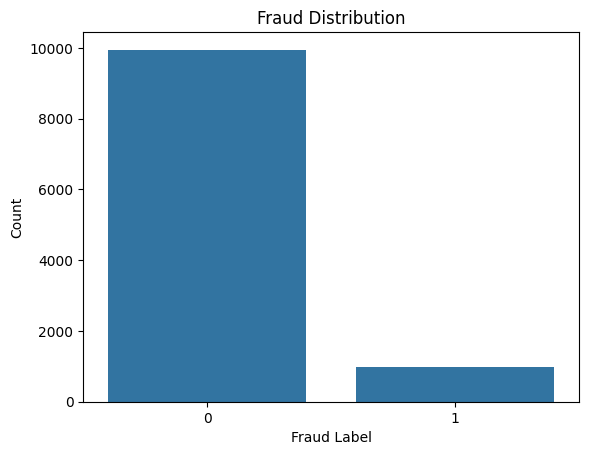

In [181]:
# Fraud distribution
sns.countplot(x="is_fraud", data=df)

plt.title("Fraud Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")
plt.show()


Fraud Rate by Channel:
channel
web        0.165807
atm        0.082822
mobile     0.047436
unknown    0.027027
Name: is_fraud, dtype: float64


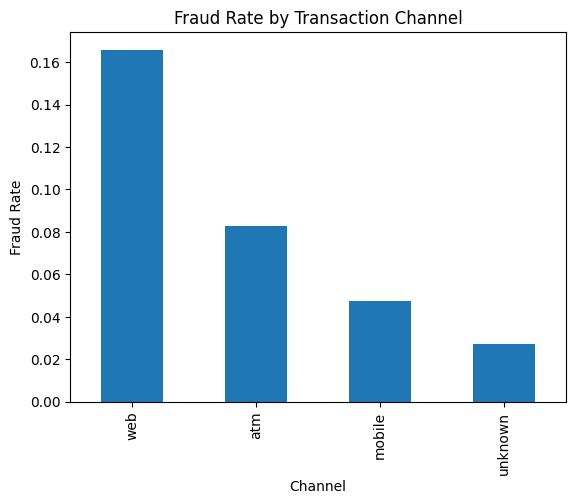

In [183]:
# Fraud rate by transaction channel
channel_fraud = (
    df.groupby("channel", observed=True)["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

print("\nFraud Rate by Channel:")
print(channel_fraud)

channel_fraud.plot(kind="bar")

plt.title("Fraud Rate by Transaction Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate")
plt.show()

In [186]:

# Transaction velocity comparison
velocity_analysis = df.groupby("is_fraud")[
    ["txn_velocity_1h", "txn_velocity_24h"]
].mean()

print("\nAverage Transaction Velocity by Fraud Label:")
print(velocity_analysis)


Average Transaction Velocity by Fraud Label:
          txn_velocity_1h  txn_velocity_24h
is_fraud                                   
0                0.155361          0.271229
1                3.872599          5.510617


In [188]:
# Device trust score comparison
device_trust = df.groupby("is_fraud")["device_trust_score"].mean()

print("\nAverage Device Trust Score by Fraud Label:")
print(device_trust)


Average Device Trust Score by Fraud Label:
is_fraud
0    0.701910
1    0.314668
Name: device_trust_score, dtype: float64


In [189]:
# IP risk score comparison
ip_risk = df.groupby("is_fraud")["ip_risk_score"].mean()

print("\nAverage IP Risk Score by Fraud Label:")
print(ip_risk)


Average IP Risk Score by Fraud Label:
is_fraud
0    0.336642
1    0.850908
Name: ip_risk_score, dtype: float64


In [190]:

# KYC tier fraud analysis
kyc_analysis = pd.crosstab(
    df["kyc_tier"],
    df["is_fraud"],
    normalize="index"
)

print("\nKYC Tier Fraud Analysis (%):")
print((kyc_analysis * 100).round(2))


KYC Tier Fraud Analysis (%):
is_fraud      0      1
kyc_tier              
enhanced  97.72   2.28
low       48.26  51.74
standard  94.80   5.20
unknown   97.48   2.52


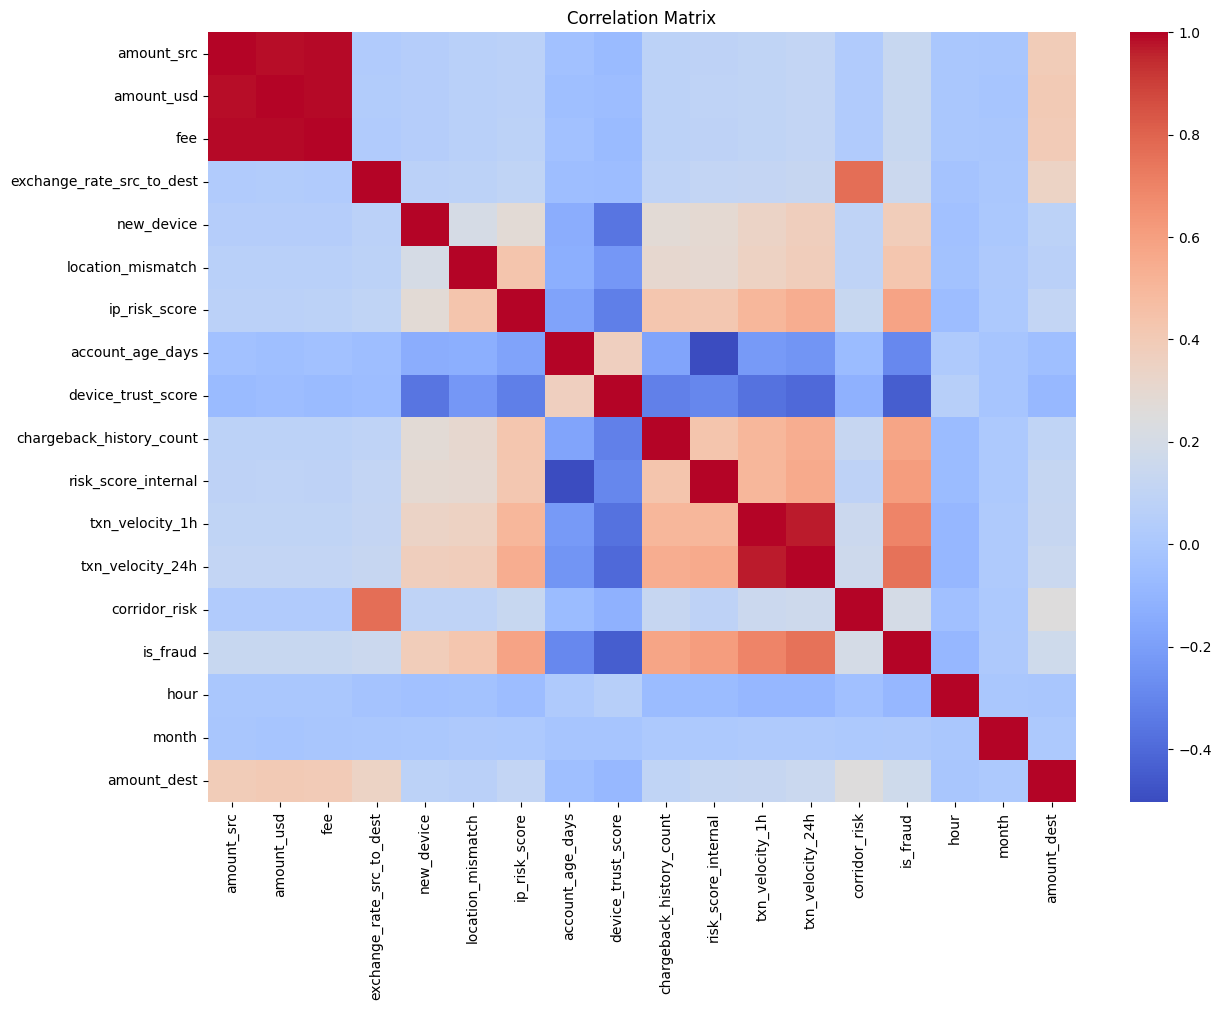

In [191]:

# Correlation matrix
numeric_df = df.select_dtypes(include=["int64", "float64", "int32"])

corr = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

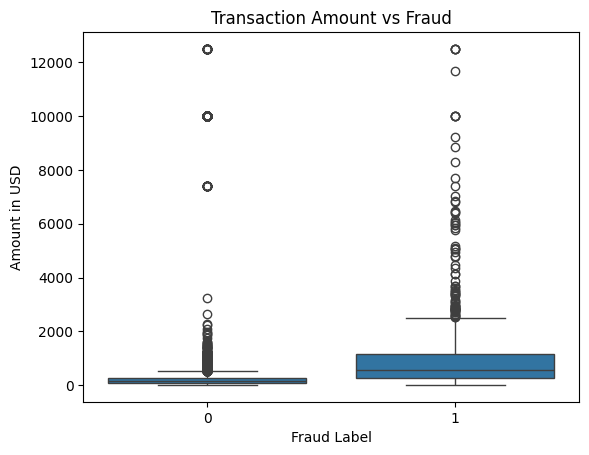

In [192]:
# Transaction amount vs fraud
sns.boxplot(
    x="is_fraud",
    y="amount_usd",
    data=df
)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud Label")
plt.ylabel("Amount in USD")
plt.show()

In [133]:
df.to_csv(
    "../data/processed/cleaned_transactions.csv",
    index=False
)